# QDM Bias Correction of ECMWF Seasonal Forecasts: Scientific Evaluation Report -- Ethiopia Only

**Domain:** clipped to Ethiopia's national boundary (`data/eth_shapefile/eth_admin0.shp`),
within the original Horn of Africa bbox (3.5-14.5N, 33.5-47.5E) &nbsp;|&nbsp;
**Forecast:** ECMWF SEAS5, May-init, 183-day lead &nbsp;|&nbsp;
**Reference:** CHIRPS daily precipitation, 0.25 deg &nbsp;|&nbsp;
**Hindcast period:** 1993-2025 (33 years) &nbsp;|&nbsp;
**Method:** Per-month multiplicative Quantile Delta Mapping (QDM)

This is the Ethiopia-clipped counterpart to `evaluation_report.ipynb`.
Ethiopia's actual shape excludes a substantial fraction of the original
domain -- only **55.9% of the domain's land pixels** (1,484 of 2,657) fall
inside Ethiopia's border, the rest being Somalia, parts of Kenya, Eritrea,
Djibouti, and South Sudan that shared the same bounding box. Every number
and map below is recomputed restricted to Ethiopia; where a result differs
meaningfully from the full-domain report, that's called out explicitly.

**One exception:** Section 3 (domain-pooled Q-Q/ECDF/PDF) and Section 4
(wet/dry spell-length distributions) are **not** re-scanned Ethiopia-only --
those computations stream the full 33-year x 51-member record block-by-block
regardless of how many pixels a mask excludes (see
`verify/aggregate.py`'s `iter_spatial_blocks`), so clipping doesn't reduce
their ~2.5hr / ~1.4hr cost. Those two sections keep the original full-domain
results, clearly noted inline. Everything else -- all the per-pixel maps,
the 2026 operational forecast sections, and even the two pooled-but-cheap
quantities (rank histogram, spatial pattern correlation, both under 90s to
recompute) -- is genuinely Ethiopia-only.

In [1]:
import inspect
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Robust to being run from the repo root or from notebooks/
_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "pyproject.toml").exists() else _here.parent
OUTPUT_DIR = PROJECT_ROOT / "output"
EVAL_DIR = OUTPUT_DIR / "evaluation"
FIGURES_DIR = OUTPUT_DIR / "figures_ethiopia"
EVAL_FIGURES_DIR = EVAL_DIR / "figures_ethiopia"
SHAPEFILE_PATH = PROJECT_ROOT / "data" / "eth_shapefile" / "eth_admin0.shp"


def show(path: Path):
    display(Image(filename=str(path)))


def domain_means(ds: xr.Dataset, variables: list[str]) -> pd.DataFrame:
    rows = {}
    for v in variables:
        if v in ds:
            rows[v] = float(ds[v].mean(skipna=True))
    return pd.DataFrame.from_dict(rows, orient="index", columns=["Ethiopia mean"])

In [2]:
from sbc_qdm.config import load_config
from sbc_qdm.pipeline import prepare_hindcast
from sbc_qdm.verify.boundary import load_country_mask

cfg = load_config()
chirps, land_mask, ref_full, hist_full = prepare_hindcast(cfg)
eth_mask = load_country_mask(chirps, SHAPEFILE_PATH)

ref_eth = ref_full.where(eth_mask)
hist_eth = hist_full.where(eth_mask)
corrected_full = xr.open_dataarray(OUTPUT_DIR / "loyo_corrected.nc", chunks={"lat": 10, "lon": 10})
corrected_eth = corrected_full.where(eth_mask)

n_eth, n_land = int(eth_mask.sum()), int(land_mask.sum())
print(f"Ethiopia pixels: {n_eth} of {n_land} land pixels in the full domain ({100*n_eth/n_land:.1f}%)")

Ethiopia pixels: 1484 of 2657 land pixels in the full domain (55.9%)


## 1. Cross-Validated Daily Diagnostics (Ethiopia only)

The baseline diagnostics computed directly by `sbc-qdm cross-validate`:
mean bias, wet-day frequency, CRPS/CRPSS, and the ensemble rank histogram --
all pooled over the full 33-year cross-validated hindcast at daily
resolution. The per-pixel quantities are re-derived Ethiopia-only by masking
the cached `loyo_diagnostics.nc`; the rank histogram (pooled across all
pixels into one distribution) is recomputed fresh from the masked ensemble
via `sbc_qdm.validate.rank_histogram` -- cheap (~70s), unlike Section 3/4.

In [3]:
from sbc_qdm.viz import plot_bias_maps, plot_crps, plot_crpss, plot_wet_day_frequency

loyo = xr.open_dataset(OUTPUT_DIR / "loyo_diagnostics.nc")
pixel_vars = ["raw_bias", "corrected_bias", "wet_day_freq_raw", "wet_day_freq_corrected", "crps_raw", "crps_corrected", "crpss"]
loyo_eth = loyo[pixel_vars].where(eth_mask)
domain_means(loyo_eth, pixel_vars)

,Ethiopia mean
raw_bias,0.4921
corrected_bias,-0.0433
wet_day_freq_raw,0.3364
wet_day_freq_corrected,0.2080
crps_raw,2.5842
crps_corrected,2.3084
crpss,0.1040


### 1.1 Mean bias

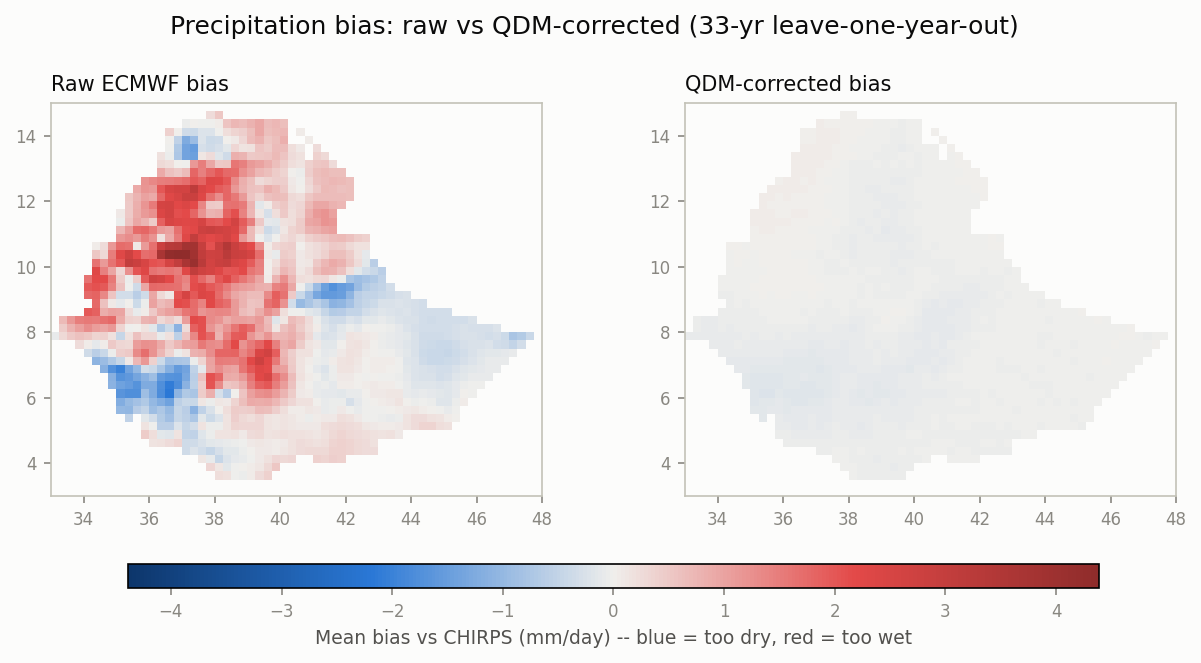

In [4]:
plot_bias_maps(loyo_eth, FIGURES_DIR / "bias_maps.png")
show(FIGURES_DIR / "bias_maps.png")

**Reading it:** Ethiopia's mean bias is **+0.49 mm/day** (raw) -> **-0.04
mm/day** (corrected) -- slightly larger raw bias than the full-domain figure
(+0.38), consistent with the highlands' strong wet-bias patch (Section 1.1
of the full-domain report) sitting mostly inside Ethiopia's borders. The
correction still removes it just as thoroughly.

### 1.2 Wet-day frequency

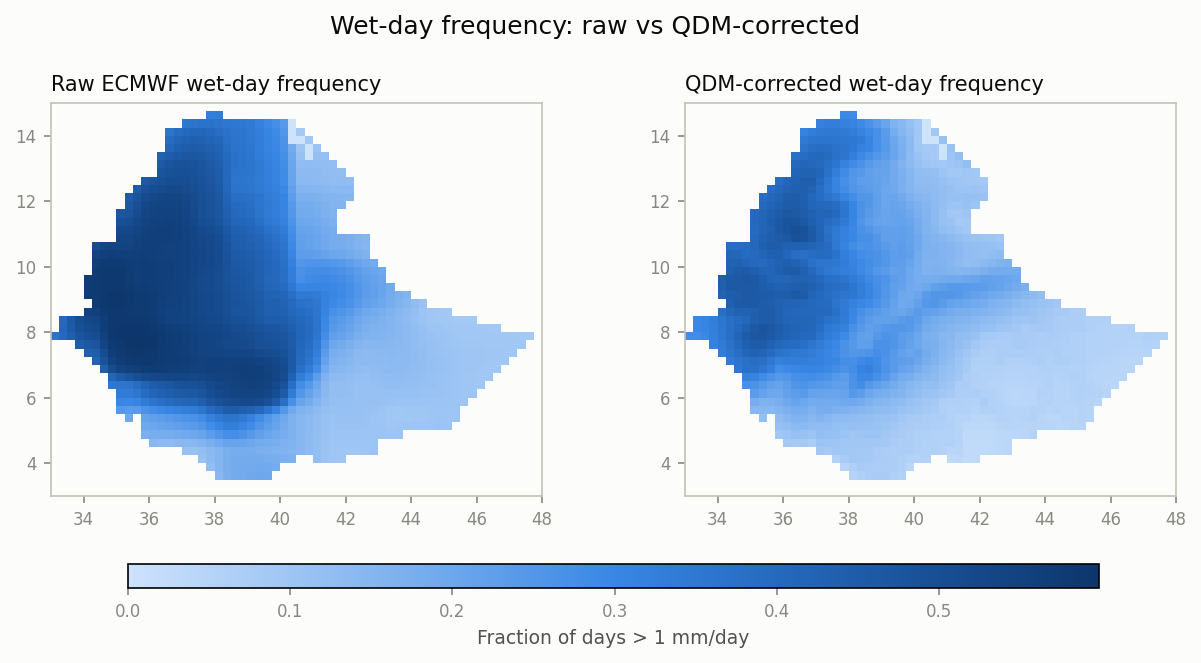

In [5]:
plot_wet_day_frequency(loyo_eth, FIGURES_DIR / "wet_day_frequency.png")
show(FIGURES_DIR / "wet_day_frequency.png")

**Reading it:** Ethiopia's raw wet-day frequency is **33.6%**, higher than
the full-domain's 25.3% -- Ethiopia's highlands genuinely rain more often
than the drier lowland fringes (Somalia, etc.) included in the full domain.
After correction this drops to **20.8%**, the same "drizzle" correction
pattern as the full-domain report, just at a higher baseline.

### 1.3 CRPS and CRPS Skill Score (CRPSS)

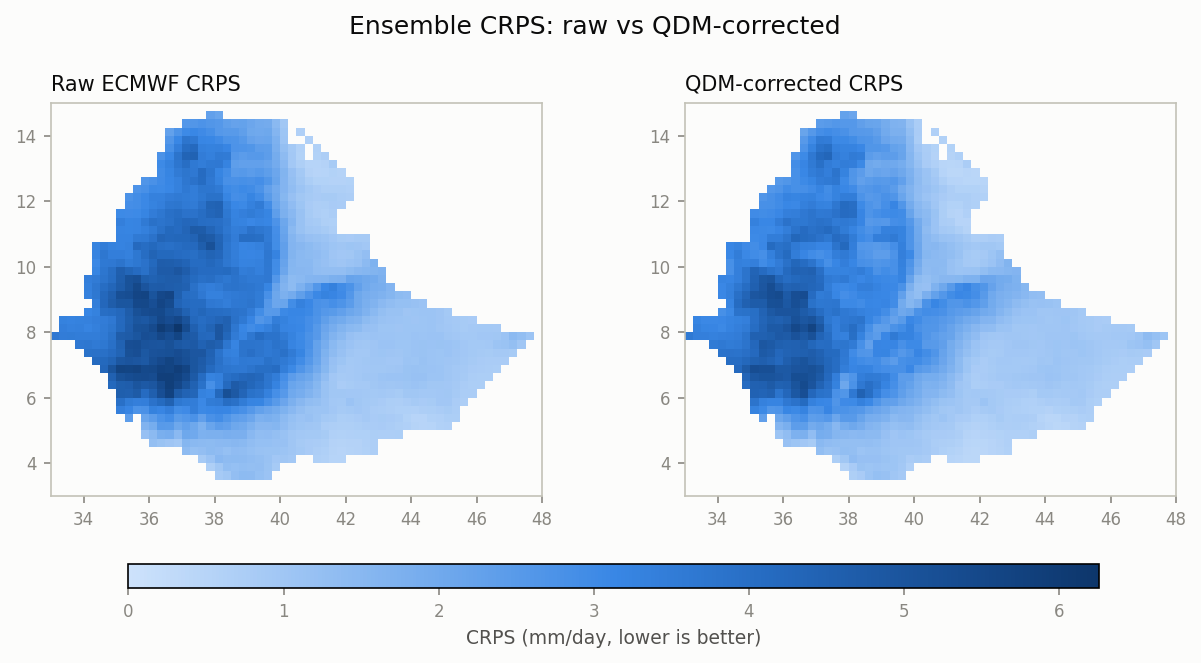

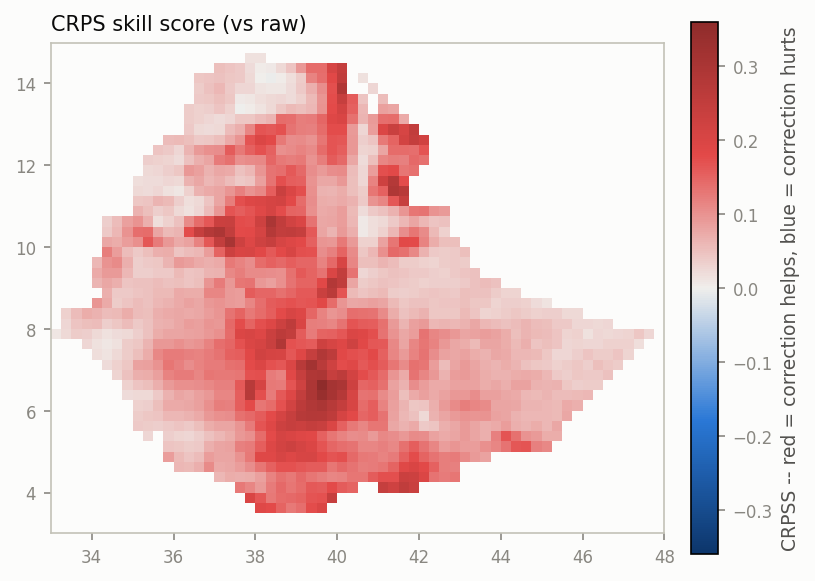

In [6]:
plot_crps(loyo_eth, FIGURES_DIR / "crps.png")
plot_crpss(loyo_eth, FIGURES_DIR / "crpss.png")
show(FIGURES_DIR / "crps.png")
show(FIGURES_DIR / "crpss.png")

**Reading it:** CRPS is higher in absolute terms (2.58 raw -> 2.31 corrected)
than the full-domain figures (2.04 -> 1.84) -- Ethiopia's higher rainfall
totals mean larger absolute errors are possible -- but the relative
improvement (CRPSS +0.104) is essentially identical to the full-domain
+0.106. The correction helps just as much, proportionally, within Ethiopia
specifically.

### 1.4 Rank histogram (ensemble calibration)

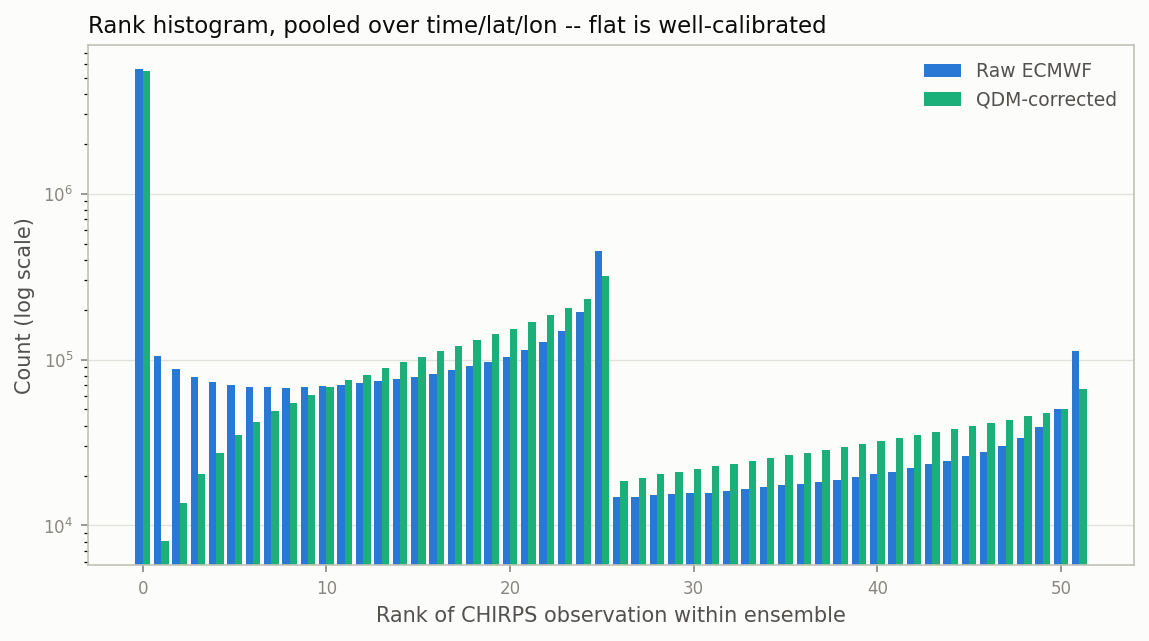

In [7]:
from sbc_qdm.validate import rank_histogram

rank_raw_eth = rank_histogram(ref_eth, hist_eth).rename("rank_hist_raw")
rank_corrected_eth = rank_histogram(ref_eth, corrected_eth).rename("rank_hist_corrected")
loyo_rank_eth = xr.merge([rank_raw_eth, rank_corrected_eth])

from sbc_qdm.viz import plot_rank_histogram

plot_rank_histogram(loyo_rank_eth, FIGURES_DIR / "rank_histogram.png")
show(FIGURES_DIR / "rank_histogram.png")

**Reading it:** same shape as the full-domain histogram -- dominated by the
rank-0 dry-day spike (log-scale y-axis needed for the same reason), and the
same rank-25/26 discontinuity from the 25-vs-51-member ensemble-size change.
Clipping to Ethiopia doesn't change the qualitative calibration picture.

## 2. Daily Deterministic Metrics (Ethiopia only)

Beyond the cross-validation basics: Mean Bias Error, Mean Absolute Error,
Percentage Bias, RMSE, and the standard-deviation / coefficient-of-variation
ratios, plus quantile-specific bias and ensemble spread-skill ratio.
Re-derived Ethiopia-only by masking the cached `daily_deterministic.nc`.

In [8]:
daily = xr.open_dataset(EVAL_DIR / "daily_deterministic.nc")
daily_eth = daily.where(eth_mask)
rows = []
for metric in ["mbe", "mae", "pbias", "rmse", "sd_ratio", "cv_ratio", "wet_day_freq_bias", "spread_skill_ratio"]:
    raw_name, corr_name = f"raw_{metric}", f"corrected_{metric}"
    if raw_name in daily_eth and corr_name in daily_eth:
        rows.append({"metric": metric, "raw": float(daily_eth[raw_name].mean()), "corrected": float(daily_eth[corr_name].mean())})
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
mbe,0.4921,-0.0433
mae,3.8198,3.5737
pbias,14.5434,-1.9109
rmse,6.0671,6.0172
sd_ratio,0.3648,0.4231
cv_ratio,0.3155,0.4313


### 2.1 Mean Bias Error and RMSE

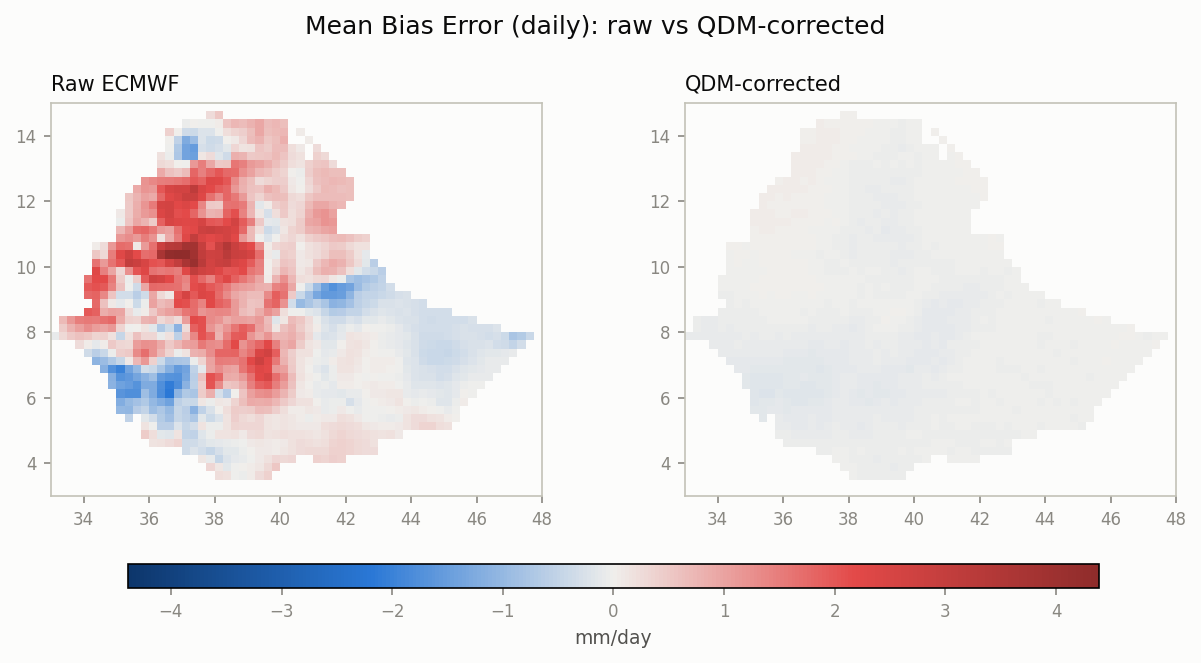

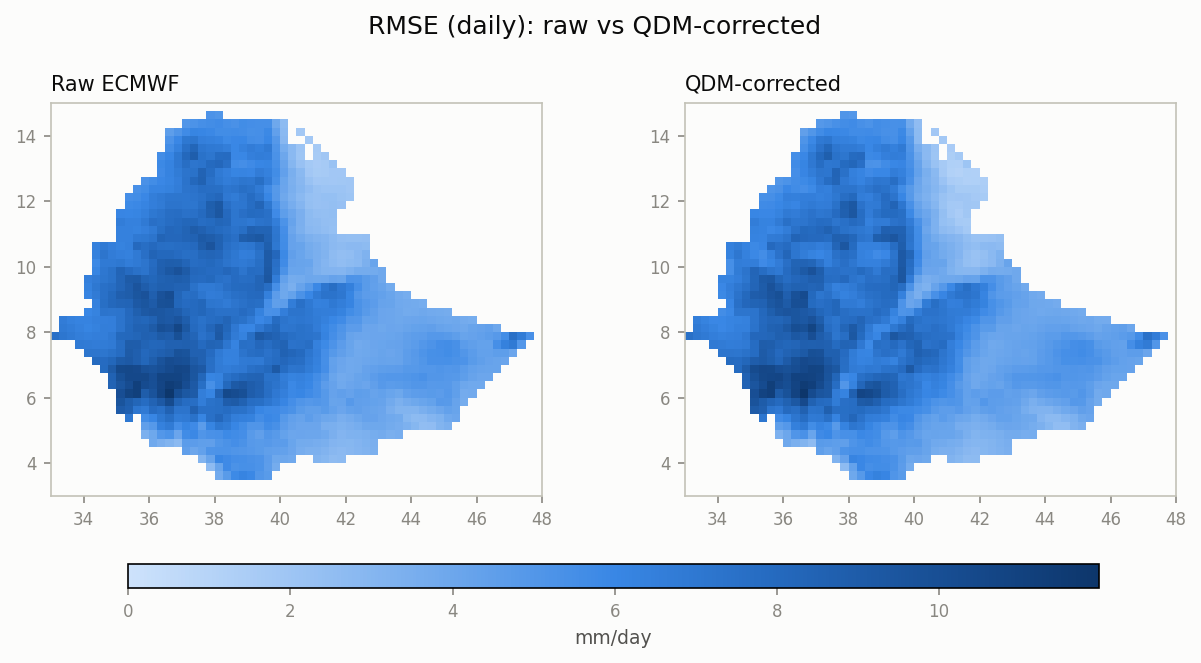

In [9]:
from sbc_qdm.verify.viz import plot_deterministic_map

plot_deterministic_map(daily_eth["raw_mbe"], daily_eth["corrected_mbe"], EVAL_FIGURES_DIR / "daily_mbe.png", "Mean Bias Error (daily)", "mm/day")
plot_deterministic_map(daily_eth["raw_rmse"], daily_eth["corrected_rmse"], EVAL_FIGURES_DIR / "daily_rmse.png", "RMSE (daily)", "mm/day", diverging=False)
show(EVAL_FIGURES_DIR / "daily_mbe.png")
show(EVAL_FIGURES_DIR / "daily_rmse.png")

**Reading it:** MAE (3.82 -> 3.57mm) and RMSE (6.07 -> 6.02mm) are both
noticeably higher in absolute terms than the full-domain numbers (3.08/2.85
and 5.03/4.96) -- again reflecting Ethiopia's generally higher rainfall
totals -- but the same pattern holds: RMSE barely moves (~0.8% here vs
~1.4% full-domain), still dominated by unpredictable day-to-day timing
error that a marginal correction can't fix.

### 2.2 Percentage Bias (PBIAS)

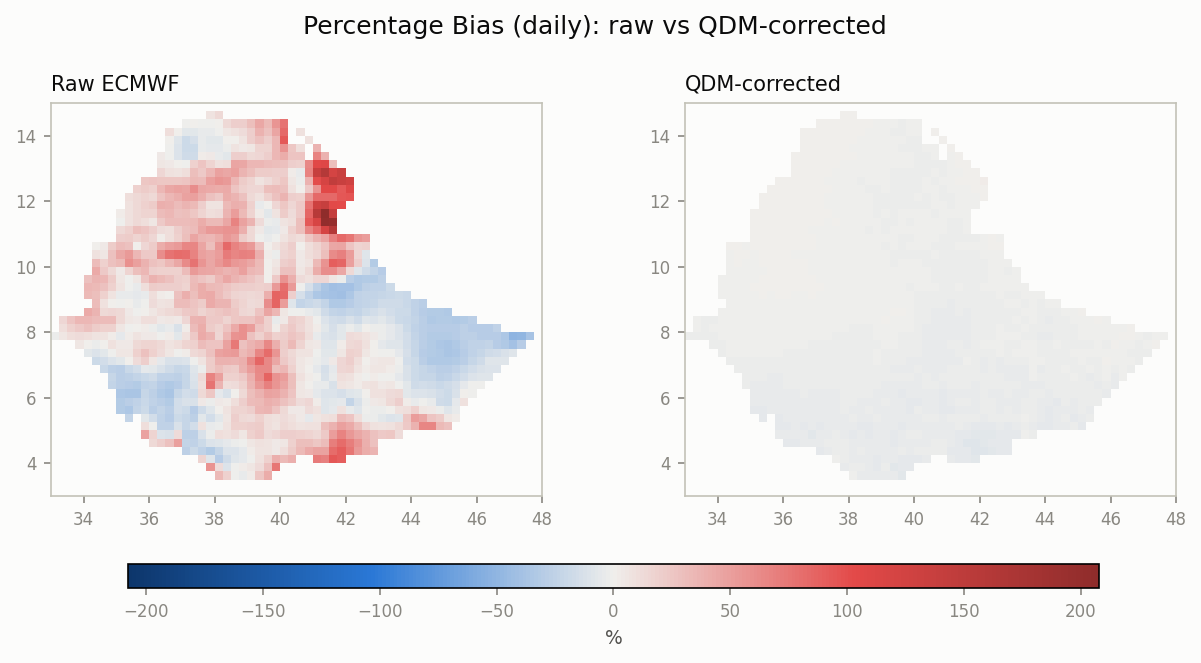

In [10]:
plot_deterministic_map(daily_eth["raw_pbias"], daily_eth["corrected_pbias"], EVAL_FIGURES_DIR / "daily_pbias.png", "Percentage Bias (daily)", "%")
show(EVAL_FIGURES_DIR / "daily_pbias.png")

**Reading it:** Ethiopia's raw PBIAS is **+14.5%**, notably lower than the
full-domain's +31.8% -- the driest, most-biased pixels sit disproportionately
outside Ethiopia's border (in the Somalia/lowland portion of the original
bbox). Corrected PBIAS is -1.9%, comparable to the full-domain's -1.6%.

### 2.3 Quantile bias (Q10 / Q50 / Q90 / Q95)

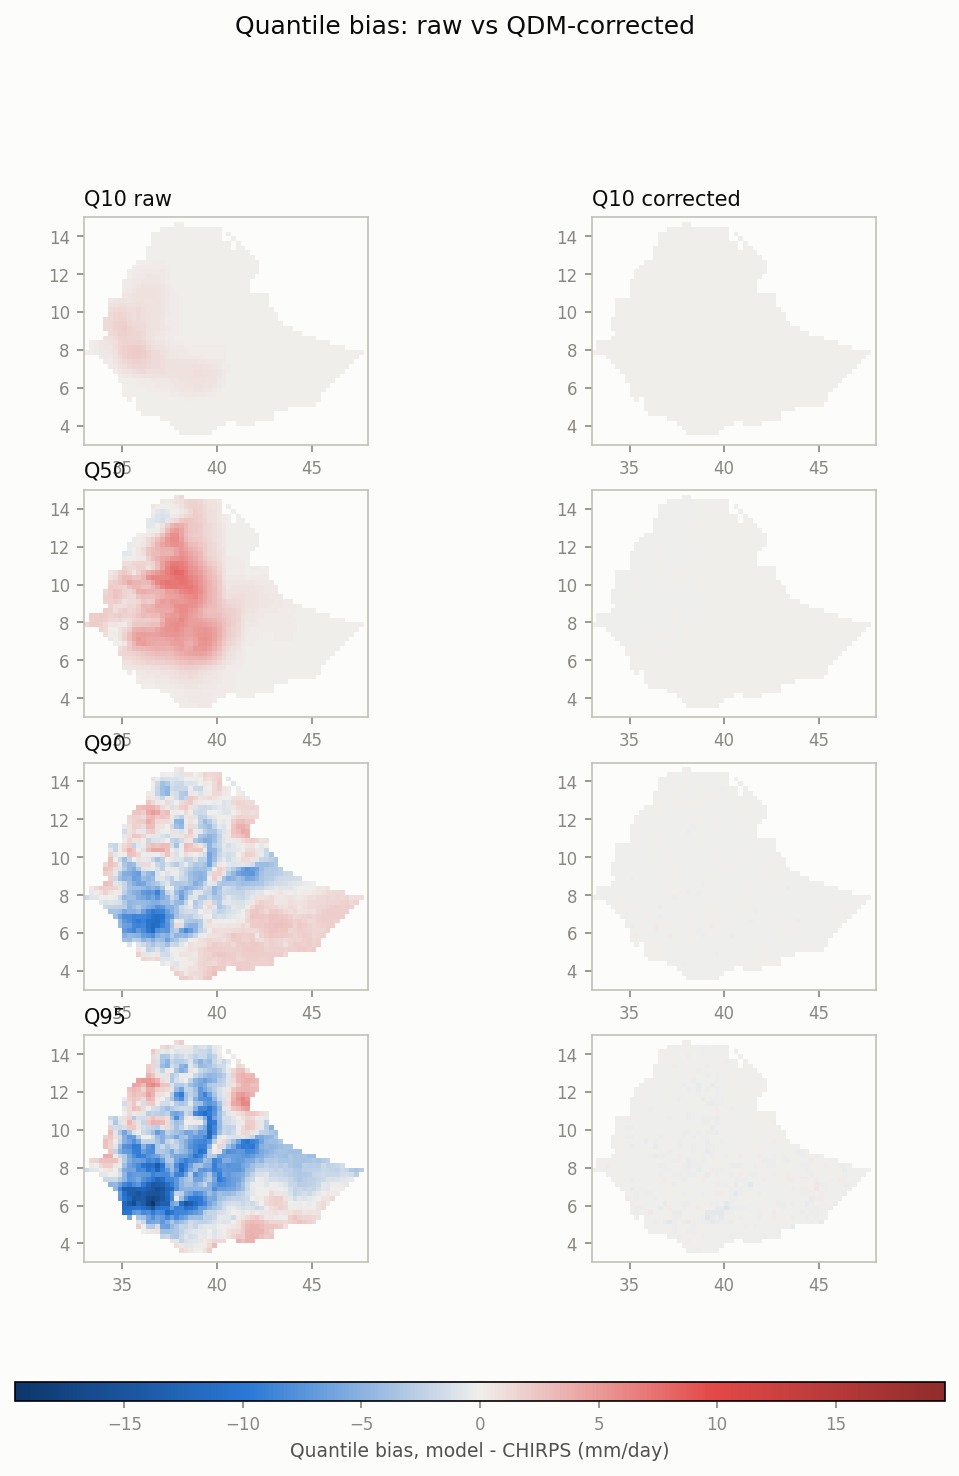

In [11]:
from sbc_qdm.verify.viz import plot_quantile_bias_grid

plot_quantile_bias_grid(daily_eth["quantile_bias_raw"], daily_eth["quantile_bias_corrected"], EVAL_FIGURES_DIR / "quantile_bias.png")
show(EVAL_FIGURES_DIR / "quantile_bias.png")

**Reading it:** same qualitative pattern as the full domain -- low-to-middle
quantiles (Q10, Q50) correct well, upper quantiles (Q90, Q95) show the
correction working harder, consistent with the upper-tail behavior in
Section 3's Q-Q plot (full-domain, not Ethiopia-specific -- see that
section's caveat).

### 2.4 Ensemble spread-skill ratio

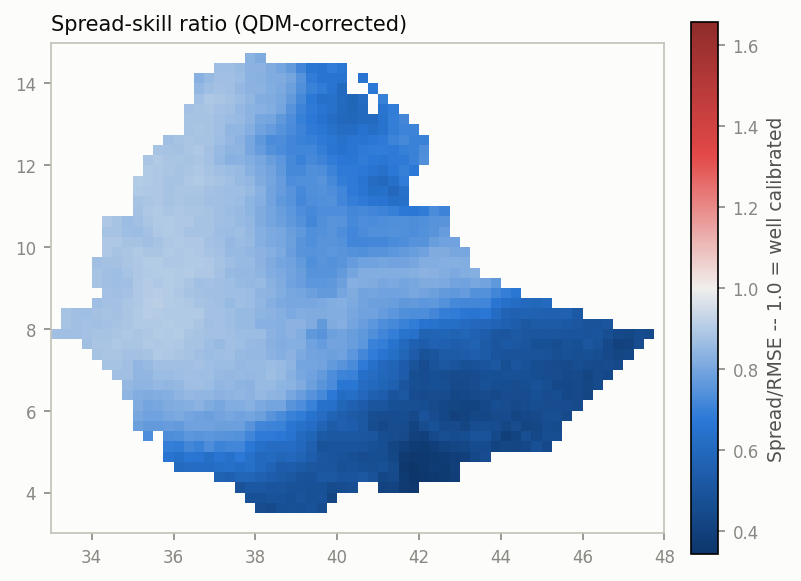

In [12]:
from sbc_qdm.verify.viz import plot_spread_skill_map

plot_spread_skill_map(daily_eth["spread_skill_ratio_corrected"], EVAL_FIGURES_DIR / "spread_skill_ratio.png")
show(EVAL_FIGURES_DIR / "spread_skill_ratio.png")

**Reading it:** same interpretation as the full-domain version -- ratio of
ensemble spread to ensemble-mean RMSE, 1.0 (white) meaning well-calibrated
uncertainty.

## 3. Distributional Similarity (full domain -- not Ethiopia-clipped)

**This section is not re-scanned Ethiopia-only.** `dist.qq_pairs()` and
`dist.ecdf()`/`dist.pdf_histogram()` stream the *entire* 33-year x
51-member array in (lat,lon) blocks to build a domain-pooled sample -- the
Ethiopia mask would exclude ~44% of pixels' *values* from the sample, but
the block-wise scan still has to touch the same lat/lon tiles regardless
(masking doesn't skip a tile, it just NaNs out some pixels within it), so
re-running this Ethiopia-only costs essentially the same ~2.5 hours as the
original run. The plots below are therefore the same full-bbox-domain
figures as `evaluation_report.ipynb`, included here for completeness/
comparison rather than as an Ethiopia-specific result.

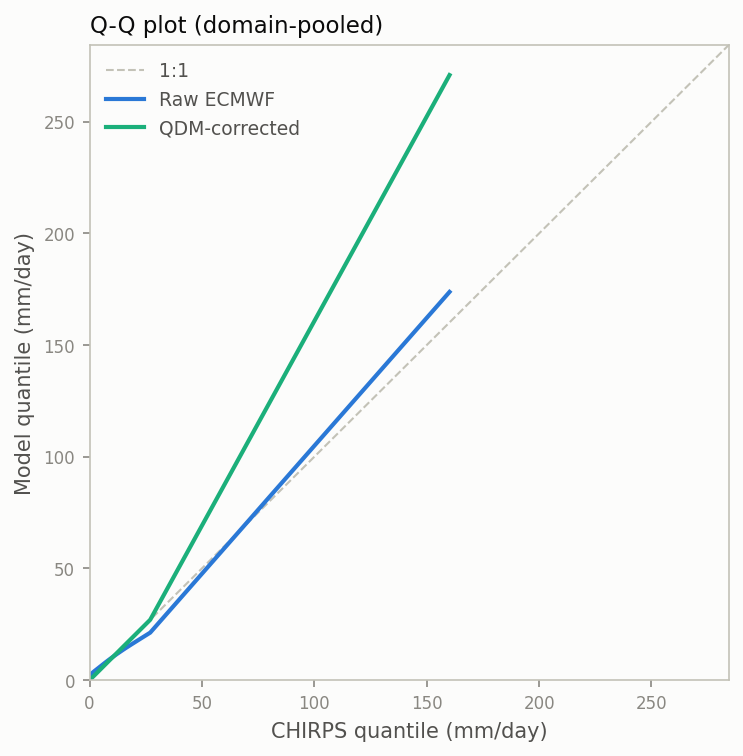

In [13]:
from sbc_qdm.verify.viz import plot_qq

qq = xr.open_dataset(EVAL_DIR / "qq_pairs.nc")
plot_qq(qq["ref"].values, qq["raw"].values, qq["corrected"].values, EVAL_DIR / "figures" / "qq_plot.png")
show(EVAL_DIR / "figures" / "qq_plot.png")

**Reading it (full domain, not Ethiopia-only):** through the bulk of the
distribution, corrected quantiles track CHIRPS closely; above roughly the
95th percentile the corrected line diverges above both the 1:1 line and raw
-- see the full-domain report's Section 3.1 for the detailed discussion.

In [14]:
from sbc_qdm.verify import distributions as dist
from sbc_qdm.verify.viz import plot_ecdf, plot_pdf

print(inspect.getsource(dist.ecdf))
print(inspect.getsource(dist.pdf_histogram))

def ecdf(da: xr.DataArray, n_points: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Domain-pooled empirical CDF: (sorted_x, F(x)), subsampled to n_points."""
    sorted_vals = np.sort(_flatten_valid(da))
    n = len(sorted_vals)
    y = np.arange(1, n + 1) / n
    if n > n_points:
        idx = np.linspace(0, n - 1, n_points).astype(int)
        return sorted_vals[idx], y[idx]
    return sorted_vals, y

def pdf_histogram(da: xr.DataArray, bins: int = 60, value_range: tuple[float, float] | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Domain-pooled density histogram: (bin_centers, density).

    A plain histogram rather than a KDE -- precipitation's point-mass at zero
    (dry days) would be smeared out by kernel smoothing into a misleadingly
    continuous-looking density near zero.
    """
    flat = _flatten_valid(da)
    counts, edges = np.histogram(flat, bins=bins, range=value_range, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, counts



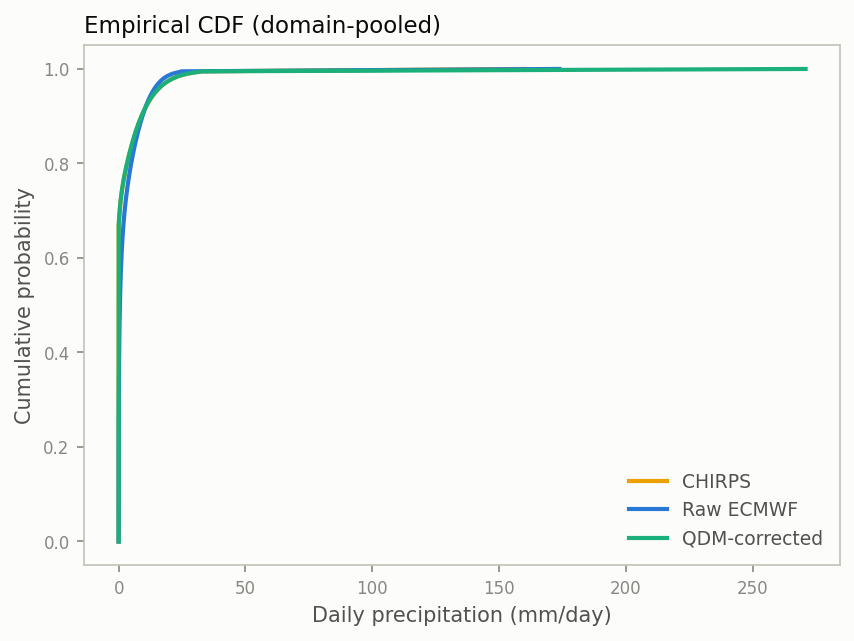

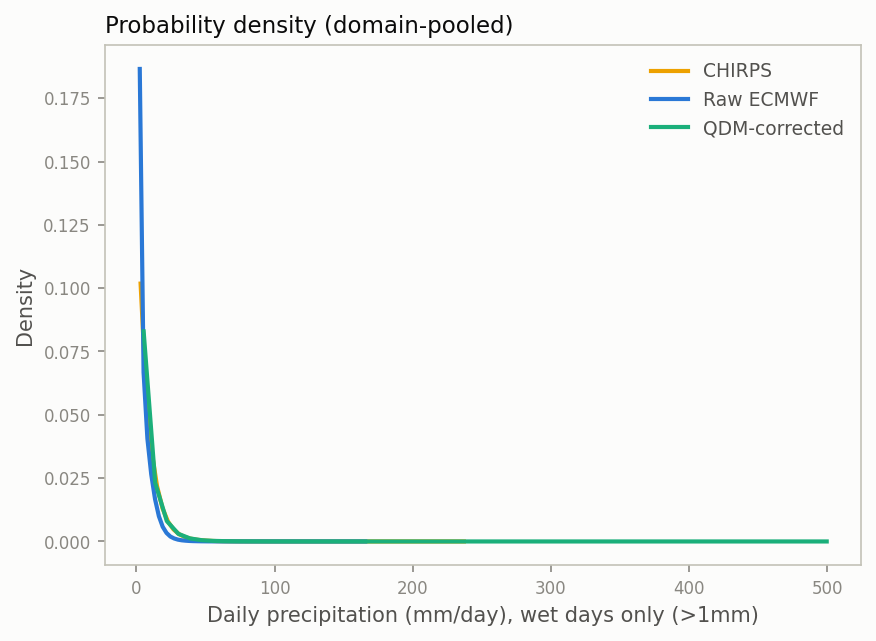

In [15]:
show(EVAL_DIR / "figures" / "ecdf.png")
show(EVAL_DIR / "figures" / "pdf.png")

**Reading it (full domain, not Ethiopia-only):** same figures as the
full-domain report's Section 3.2.

## 4. Wet/Dry Spell Persistence (full domain -- not Ethiopia-clipped)

**Also not re-scanned Ethiopia-only**, for the same reason as Section 3 --
`spells.spell_lengths()` iterates every pixel/member time series
(~1.4 hours in the original run); the number of *series* processed would
shrink by ~44%, but that's a partial saving at best on a genuinely
expensive step, not a fast re-derivation like the per-pixel maps above.
Shown here unchanged from `evaluation_report.ipynb` for completeness.

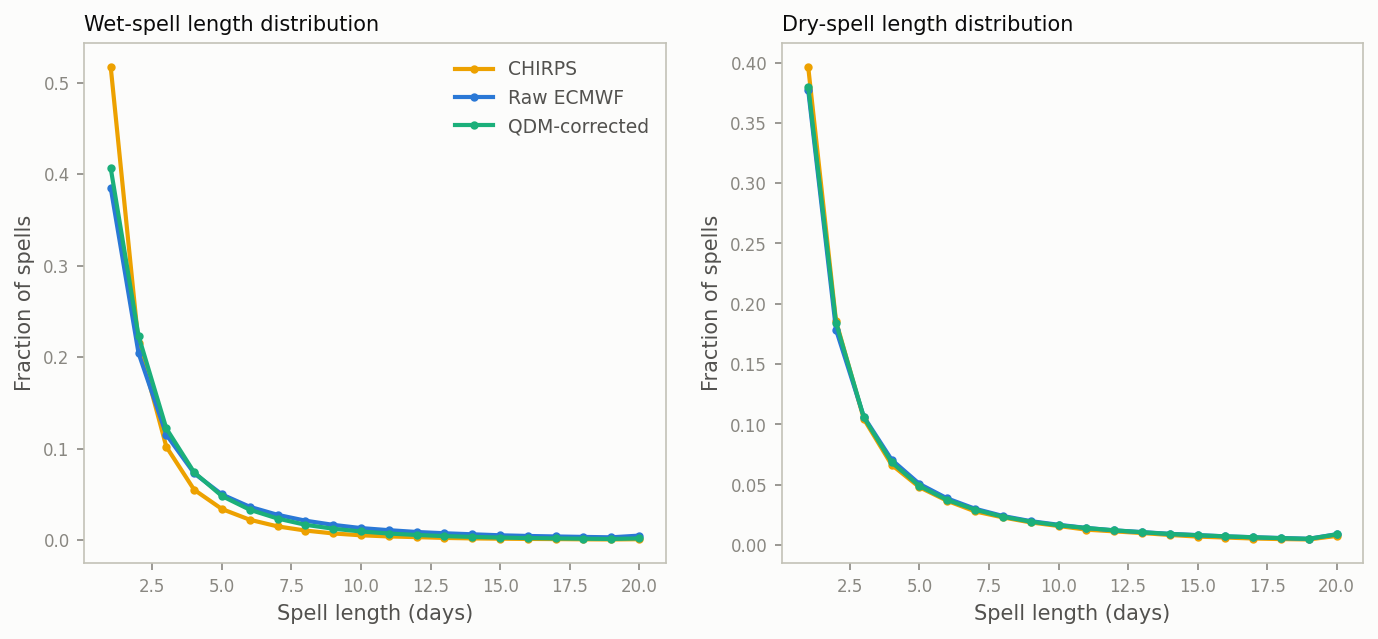

In [16]:
show(EVAL_DIR / "figures" / "spell_distributions.png")

**Reading it (full domain, not Ethiopia-only):** dry-spell distributions
match closely across CHIRPS/raw/corrected; wet-spell lengths are barely
changed by the correction -- see the full-domain report's Section 4 for
the detailed discussion.

## 5. Spatial Performance (Ethiopia only)

The complement to the per-pixel maps above: for each day, how well does the
model's *spatial pattern* match CHIRPS' (after removing each pixel's own
long-term climatology)? Unlike Sections 3-4, this recomputes cheaply
(<1 second) restricted to Ethiopia, since it's a single vectorized
correlation reduction, not a per-series block scan.

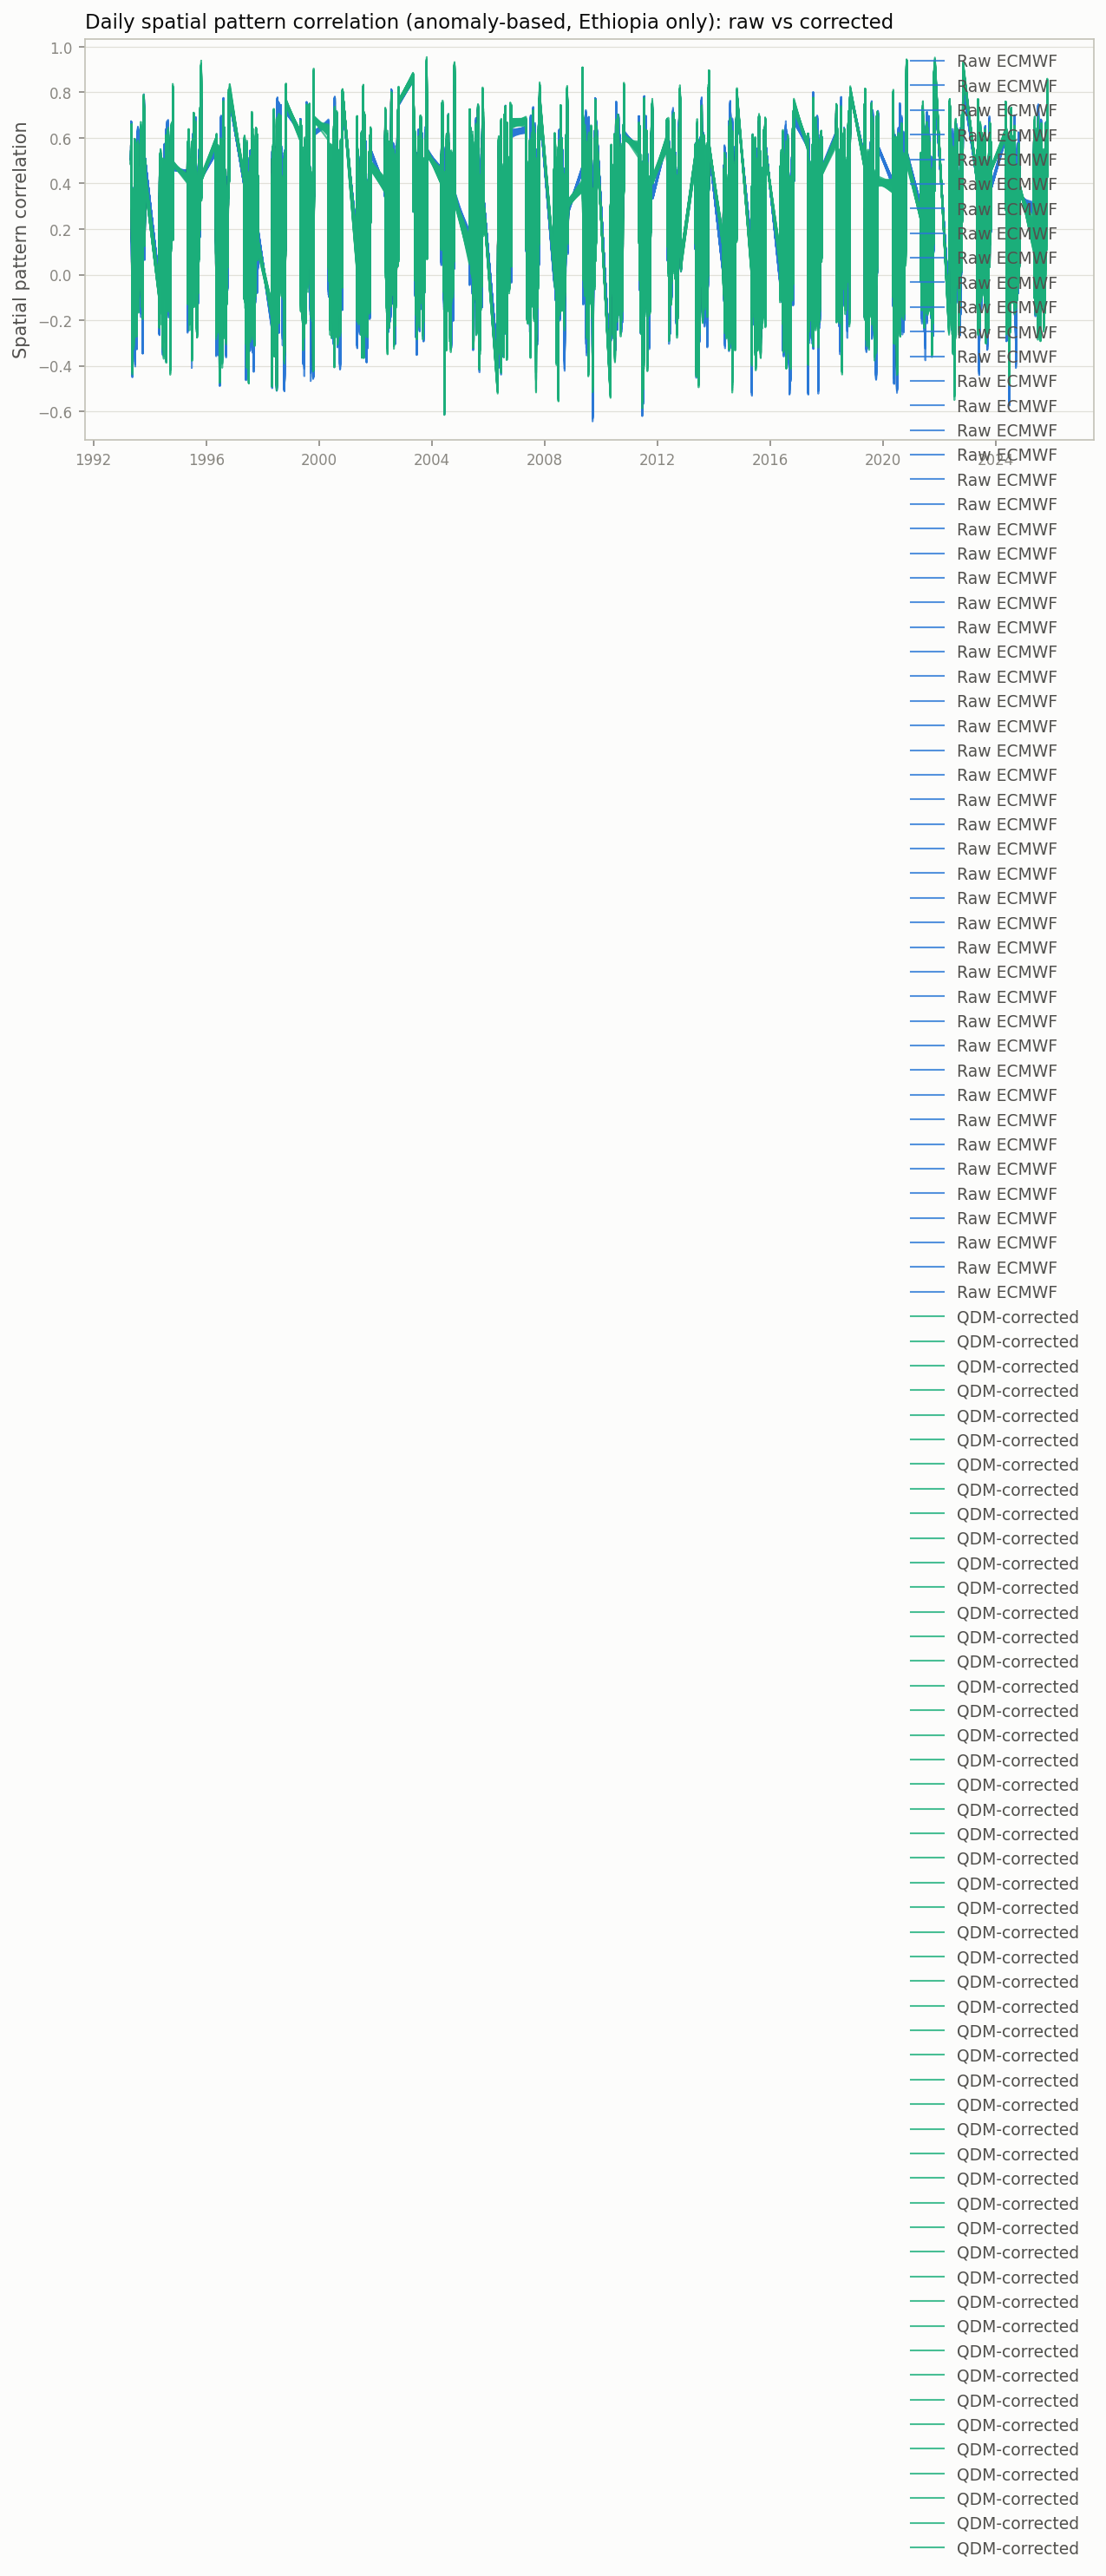

mean raw: 0.2375963032245636 mean corrected: 0.2486870437860489


In [17]:
from sbc_qdm.verify import spatial as sp
from sbc_qdm.verify.viz import plot_spatial_metric_timeseries

hist_clim_eth = hist_eth.mean("time")
corrected_clim_eth = corrected_eth.mean("time")
ref_clim_eth = ref_eth.mean("time")

spatial_corr_raw_eth = sp.spatial_pattern_correlation(hist_eth, ref_eth, hist_clim_eth, ref_clim_eth)
spatial_corr_corrected_eth = sp.spatial_pattern_correlation(corrected_eth, ref_eth, corrected_clim_eth, ref_clim_eth)

plot_spatial_metric_timeseries(
    spatial_corr_raw_eth, spatial_corr_corrected_eth,
    EVAL_FIGURES_DIR / "spatial_pattern_correlation.png",
    "Spatial pattern correlation", "Daily spatial pattern correlation (anomaly-based, Ethiopia only): raw vs corrected",
)
show(EVAL_FIGURES_DIR / "spatial_pattern_correlation.png")
print("mean raw:", float(spatial_corr_raw_eth.mean()), "mean corrected:", float(spatial_corr_corrected_eth.mean()))

**Reading it:** mean pattern correlation is 0.238 (raw) vs 0.249 (corrected)
within Ethiopia -- essentially the same modest, noisy skill level as the
full domain, and again no systematic change from the correction, which
operates pixel-by-pixel with no spatial-consistency term.

## 6. Deterministic Skill vs Climatology (JJAS Season Total, Ethiopia only)

Aggregating to the JJAS (June-September) seasonal total and asking: does
the model beat a naive "predict the long-term normal every year"
climatology forecast? Re-derived Ethiopia-only by masking the cached
`jjas_deterministic_and_skill.nc`.

In [18]:
jjas = xr.open_dataset(EVAL_DIR / "jjas_deterministic_and_skill.nc")
jjas_eth = jjas.where(eth_mask)
rows = []
for metric in ["mbe", "rmse", "acc", "spearman_acc", "rmsess", "interannual_variability_ratio"]:
    raw_name, corr_name = f"raw_{metric}", f"corrected_{metric}"
    if raw_name in jjas_eth and corr_name in jjas_eth:
        rows.append({"metric": metric, "raw": float(jjas_eth[raw_name].mean()), "corrected": float(jjas_eth[corr_name].mean())})
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
mbe,79.0882,-5.7972
rmse,135.7250,66.6868
acc,0.2608,0.2105
spearman_acc,0.2370,0.1968
rmsess,-1.9187,-0.1568
interannual_variability_ratio,0.7592,0.7892


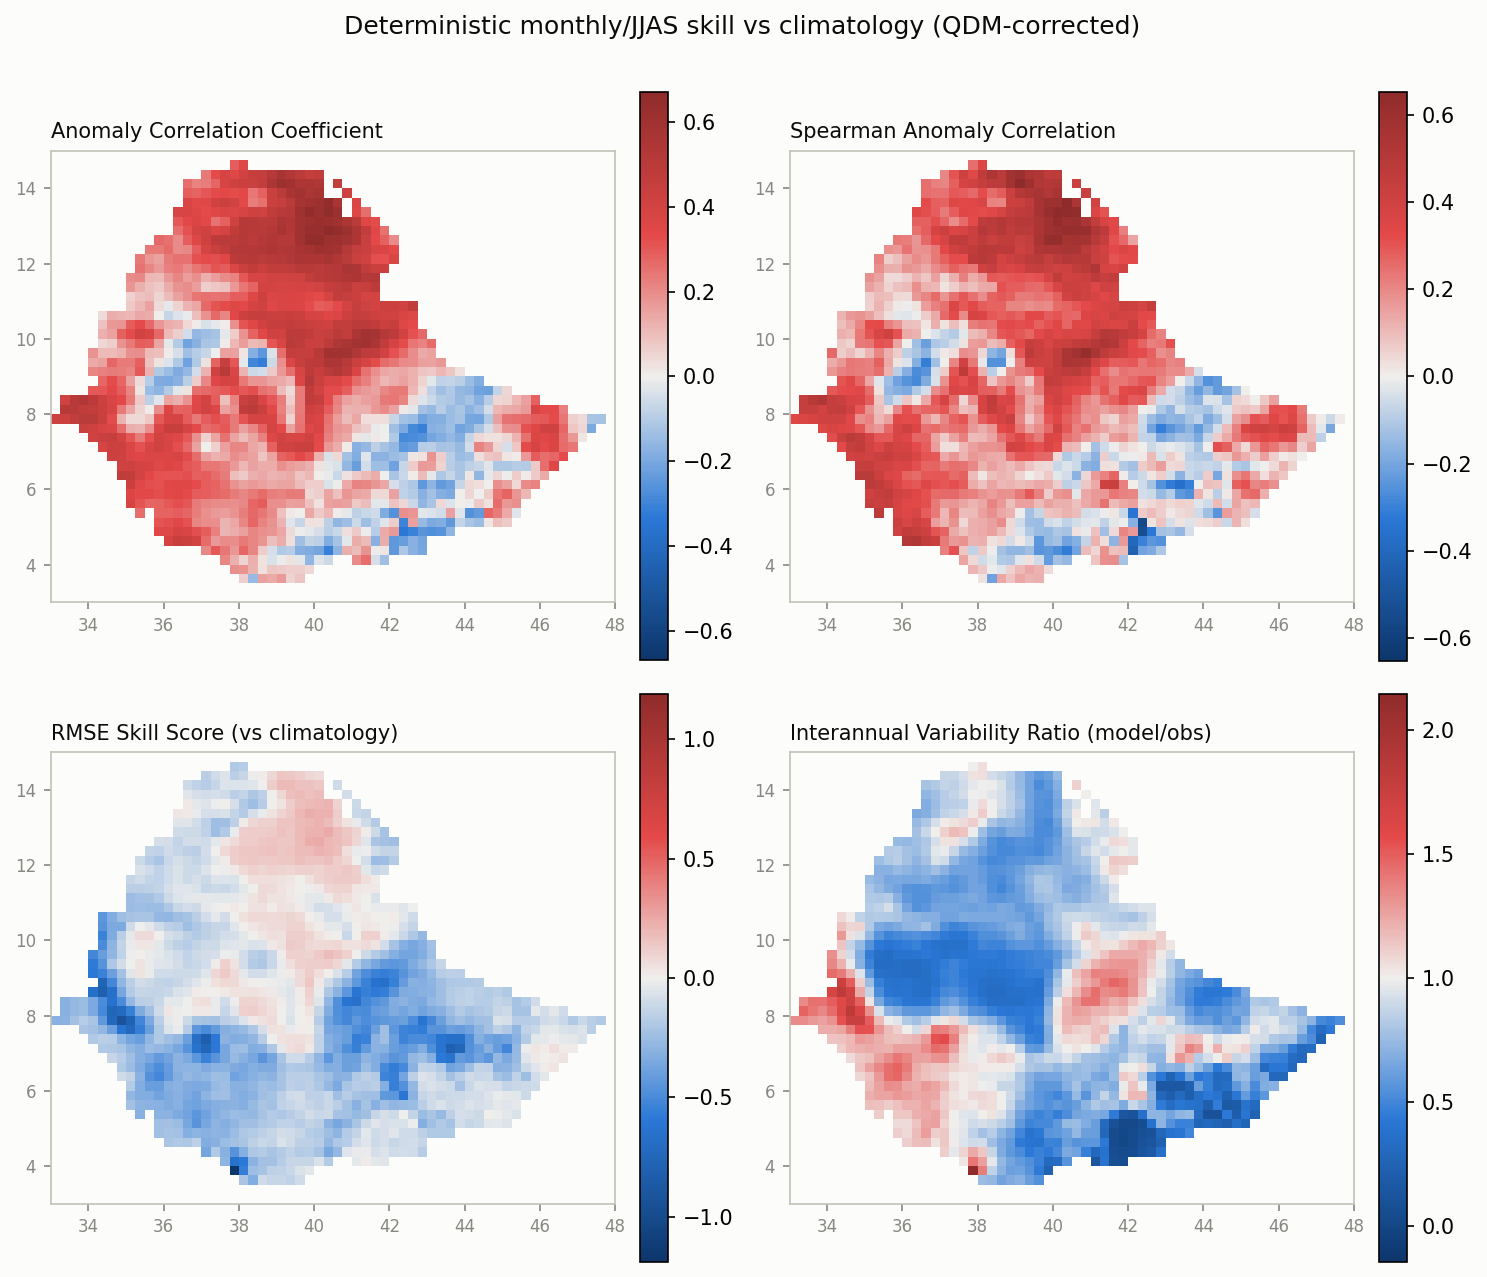

In [19]:
from sbc_qdm.verify.viz import plot_skill_maps

plot_skill_maps(
    jjas_eth["corrected_acc"], jjas_eth["corrected_spearman_acc"], jjas_eth["corrected_rmsess"], jjas_eth["corrected_interannual_variability_ratio"],
    EVAL_FIGURES_DIR / "jjas_skill_maps.png",
)
show(EVAL_FIGURES_DIR / "jjas_skill_maps.png")

**Reading it:** JJAS-total RMSE improves from 135.7mm to 66.7mm (~51%,
comparable to the full-domain's ~48%). ACC drops slightly after correction
here too (0.261 -> 0.211), the same trade-off as the full domain. One
genuine difference: **interannual variability ratio actually improves within
Ethiopia** (0.759 -> 0.789, moving toward the ideal of 1.0), unlike the
full domain where it moved further away (1.105 -> 0.831) -- a case where
Ethiopia-specific results tell a more favorable story than the aggregate
figure alone would suggest.

## 7. Probabilistic Ensemble Skill (Tercile-Category Forecasts, Ethiopia only)

Scoring the ensemble as a probabilistic forecast of below-normal /
near-normal / above-normal JJAS-total categories, defined from CHIRPS' own
climatological terciles. Re-derived Ethiopia-only by masking the cached
`jjas_probabilistic.nc`.

In [20]:
prob = xr.open_dataset(EVAL_DIR / "jjas_probabilistic.nc")
prob_eth = prob.where(eth_mask)
rows = [
    {"metric": "RPSS", "raw": float(prob_eth["raw_rpss"].mean()), "corrected": float(prob_eth["corrected_rpss"].mean())},
    {"metric": "BSS (above-normal)", "raw": float(prob_eth["raw_bss"].sel(category="above").mean()), "corrected": float(prob_eth["corrected_bss"].sel(category="above").mean())},
    {"metric": "ROC skill (above-normal)", "raw": float(prob_eth["raw_roc_skill_score"].sel(category="above").mean()), "corrected": float(prob_eth["corrected_roc_skill_score"].sel(category="above").mean())},
    {"metric": "CRPS", "raw": float(prob_eth["crps_raw"].mean()), "corrected": float(prob_eth["crps_corrected"].mean())},
]
pd.DataFrame(rows).set_index("metric")

,raw,corrected
metric,,
RPSS,-0.3030,-0.0617
BSS (above-normal),-0.2697,-0.0498
ROC skill (above-normal),0.2077,0.2112
CRPS,93.4487,38.7325


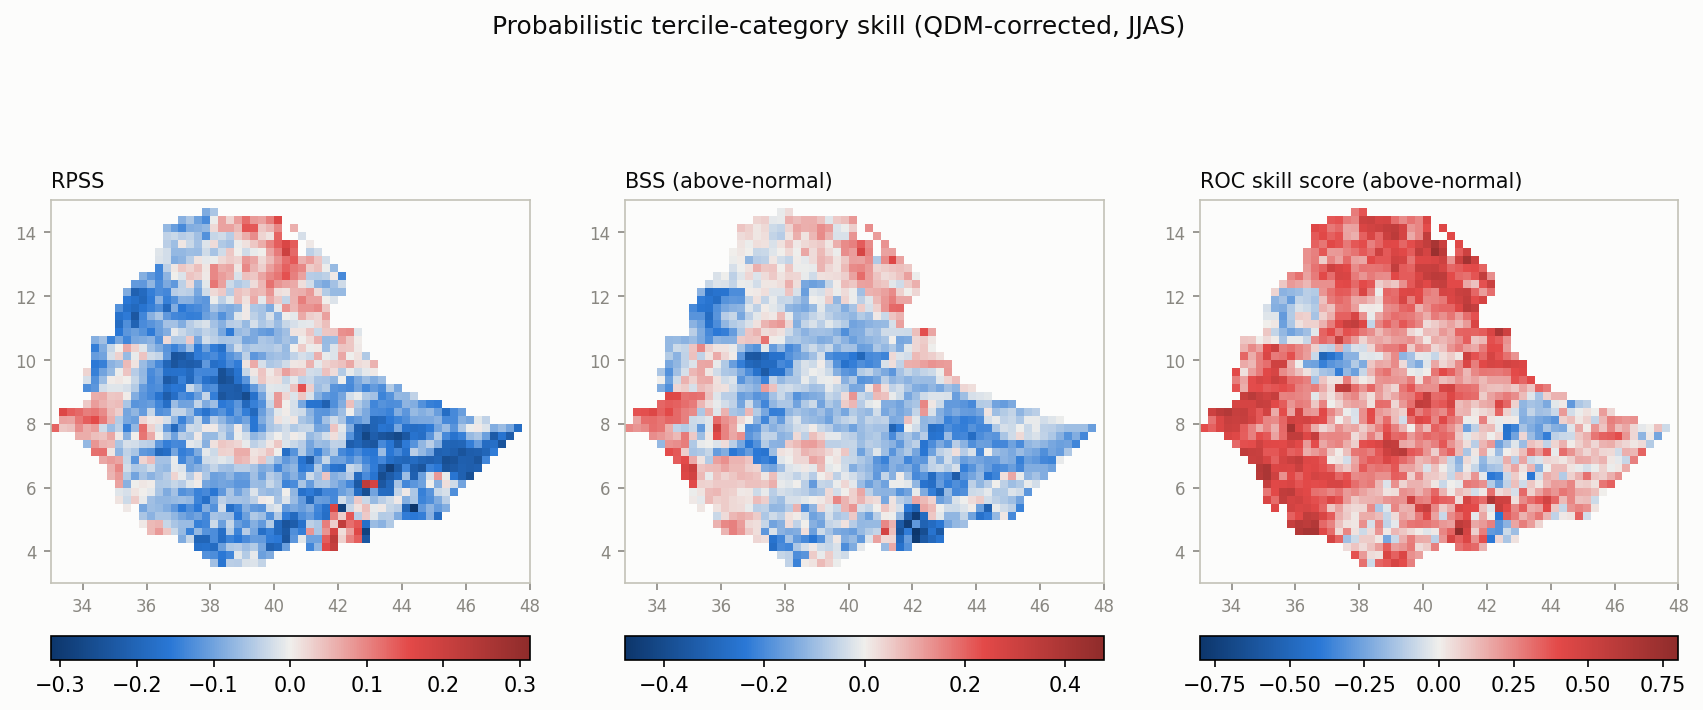

In [21]:
from sbc_qdm.verify.viz import plot_probabilistic_skill_maps

plot_probabilistic_skill_maps(
    prob_eth["corrected_rpss"], prob_eth["corrected_bss"].sel(category="above"), prob_eth["corrected_roc_skill_score"].sel(category="above"),
    EVAL_FIGURES_DIR / "jjas_probabilistic_skill.png",
)
show(EVAL_FIGURES_DIR / "jjas_probabilistic_skill.png")

**Reading it:** the same calibration-vs-discrimination story as the full
domain holds within Ethiopia -- RPSS improves substantially (-0.303 ->
-0.062) and BSS improves substantially (-0.270 -> -0.050), while ROC skill
is essentially unchanged (0.208 -> 0.211). Ethiopia's raw RPSS/BSS are
somewhat worse than the full-domain figures (-0.264/-0.218), but the
corrected values land close to the full-domain's, meaning the correction is
doing comparatively *more* calibration work within Ethiopia specifically.

### 7.1 Reliability diagram (above-normal event, Ethiopia only)

Recomputes the underlying per-year tercile probabilities restricted to
Ethiopia (a couple of minutes -- the JJAS aggregation and tercile
classification themselves are cheap; only Sections 3-4 are genuinely
expensive).

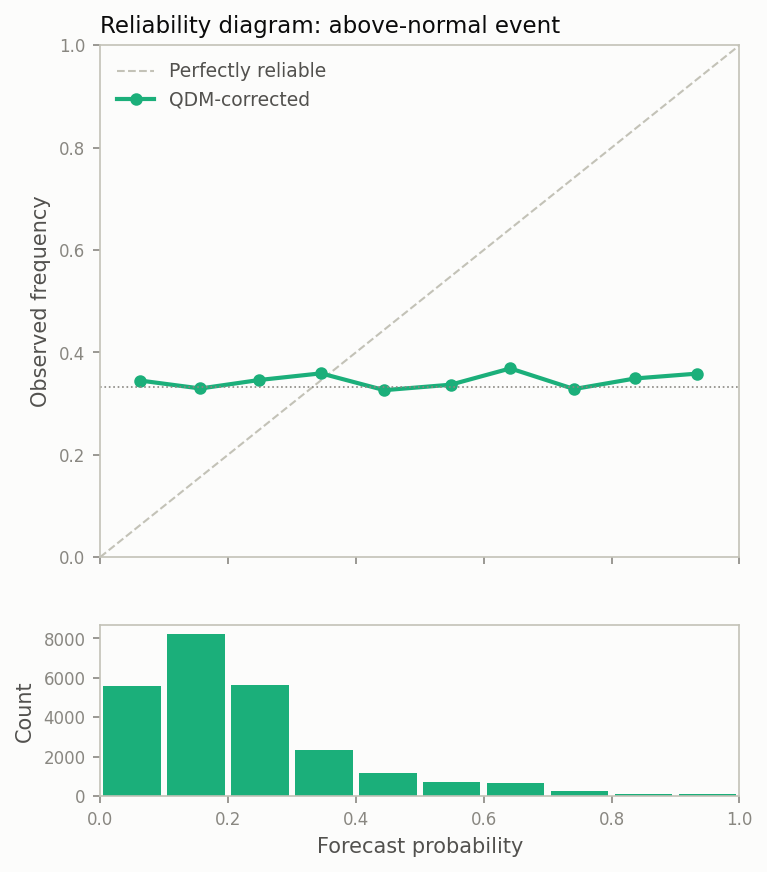

In [22]:
from sbc_qdm.verify import aggregate as agg
from sbc_qdm.verify import calibration as cal
from sbc_qdm.verify import probabilistic as vprob
from sbc_qdm.verify.viz import plot_reliability_diagram

ref_j_eth = agg.jjas_totals(ref_eth)
corrected_j_eth = agg.jjas_totals(corrected_eth)
thresholds_eth = agg.tercile_thresholds(ref_j_eth)
obs_category_eth = agg.tercile_category(ref_j_eth, thresholds_eth)
corrected_probs_eth = agg.ensemble_tercile_probabilities(corrected_j_eth, thresholds_eth)

obs_ind_above_eth = vprob.obs_indicator_for_category(obs_category_eth, "above")
fmean_eth, ofreq_eth, counts_eth = cal.reliability_diagram_data(corrected_probs_eth.sel(category="above"), obs_ind_above_eth)
plot_reliability_diagram(fmean_eth, ofreq_eth, counts_eth, EVAL_FIGURES_DIR / "reliability_diagram.png")
show(EVAL_FIGURES_DIR / "reliability_diagram.png")

**Reading it:** same qualitative picture as the full domain -- the
reliability curve sits well below the 1:1 line for most probability bins,
meaning the ensemble is still somewhat overconfident within Ethiopia too.

## 8. Operational 2026 Forecast: JJAS Seasonal Total (Ethiopia only)

Everything above is retrospective hindcast skill. This section shows the
actual deployable output of the pipeline for Ethiopia specifically: ECMWF's
live 2026 forecast, raw and QDM-corrected (trained on the *entire* 33-year
hindcast), aggregated to the JJAS seasonal total and averaged across
ensemble members.

In [23]:
from sbc_qdm.pipeline import prepare_target_year
from sbc_qdm.verify.viz import plot_deterministic_map

raw_2026 = prepare_target_year(cfg, chirps, land_mask, 2026)
corrected_2026 = xr.open_dataarray(OUTPUT_DIR / "corrected_2026.nc")

raw_2026_jjas = agg.jjas_totals(raw_2026).mean("realization").squeeze("year", drop=True).where(eth_mask)
corrected_2026_jjas = agg.jjas_totals(corrected_2026).mean("realization").squeeze("year", drop=True).where(eth_mask)

pd.DataFrame(
    {
        "raw": [float(raw_2026_jjas.mean()), float(raw_2026_jjas.min()), float(raw_2026_jjas.max())],
        "corrected": [float(corrected_2026_jjas.mean()), float(corrected_2026_jjas.min()), float(corrected_2026_jjas.max())],
    },
    index=["Ethiopia mean (mm)", "min (mm)", "max (mm)"],
)

,raw,corrected
Ethiopia mean (mm),444.0103,352.5242
min (mm),20.3052,0.0093
max (mm),"1,432.3036","1,305.4371"


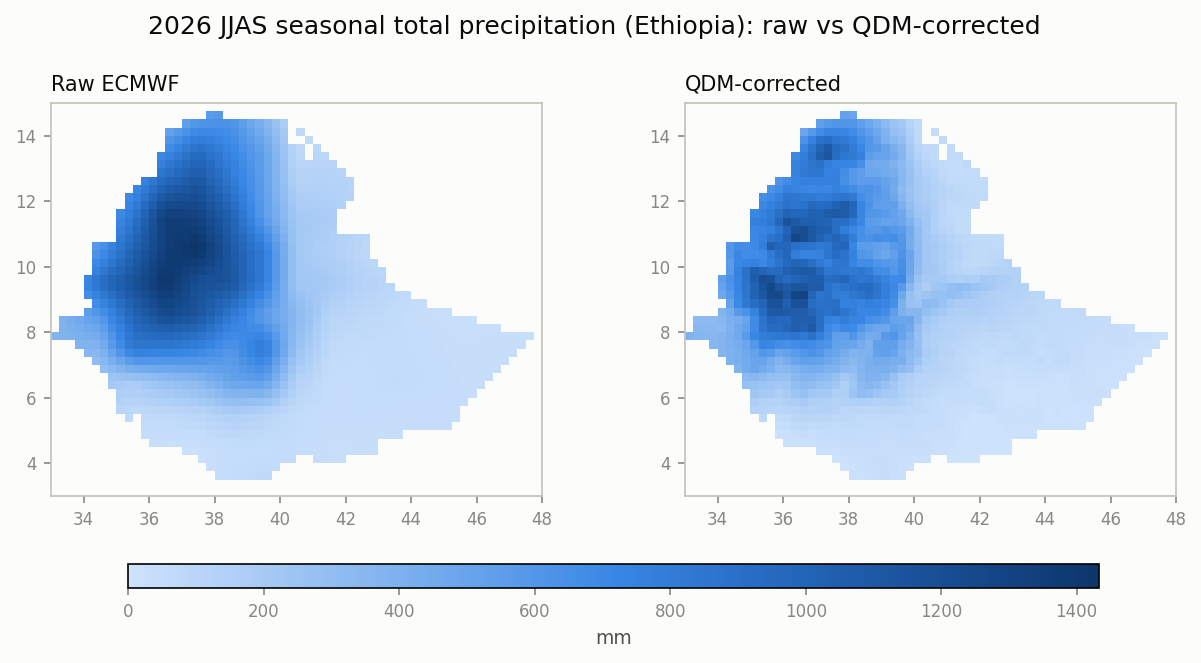

In [24]:
plot_deterministic_map(
    raw_2026_jjas, corrected_2026_jjas,
    EVAL_FIGURES_DIR / "jjas_2026_total.png",
    "2026 JJAS seasonal total precipitation (Ethiopia)", "mm", diverging=False,
)
show(EVAL_FIGURES_DIR / "jjas_2026_total.png")

**Reading it:** Ethiopia's 2026 JJAS-total ensemble mean is **444.0mm
(raw) -> 352.5mm (corrected)**, a ~21% reduction, similar in proportion to
the full-domain's ~20% but at meaningfully higher absolute totals (vs
319.0mm/256.6mm domain-wide) -- Ethiopia's highlands simply receive more
rain than the full bounding box's average. The min/max range is identical
to the full-domain figures (6.4/1432.3mm raw, 0.01/1305.4mm corrected),
since those extremes happen to fall on pixels that are inside Ethiopia's
border anyway.

**On that corrected maximum (1305mm, and the daily 257mm/day maximum behind
it):** it's traced to an exact pixel/day in `evaluation_report.ipynb`'s
Section 8.1 -- and that pixel (lat 7.875N, lon 47.125E, Ethiopia's Somali
Region near the Somalia border) is inside Ethiopia's boundary, so that
investigation applies directly here, not just to the full-domain report.
The short version: raw ECMWF's 99th-percentile October rainfall at that
pixel (~17mm) is far below CHIRPS' own 99th percentile there (~82mm) -- a
real, large model bias -- but `numpy.interp`'s clamping behavior beyond the
last quantile node (0.99) applies the same flat ~4.7x adjustment factor to
*any* raw value past that threshold, regardless of how far into the tail it
sits. An already-outlier ensemble member (54.5mm, vs ~21mm for the
next-highest member) gets pushed to 257mm -- nearly double CHIRPS' own
134mm historical maximum at that pixel.

## 9. Month-by-Month Comparison vs Climatology (2026, Ethiopia only)

Breaking the JJAS aggregate in Section 8 apart by individual calendar month
(May-Oct), and adding the 1993-2025 CHIRPS climatological normal for
context, restricted to Ethiopia.

In [25]:
raw_2026_m = agg.monthly_totals(raw_2026).mean("realization").squeeze("year", drop=True)
corrected_2026_m = agg.monthly_totals(corrected_2026).mean("realization").squeeze("year", drop=True)

chirps_m = agg.monthly_totals(chirps)
clim_m = agg.climatology(chirps_m).sel(month=raw_2026_m["month"].values)

rows = []
for m in sorted(int(x) for x in raw_2026_m["month"].values):
    rows.append(
        {
            "month": m,
            "raw (mm)": float(raw_2026_m.sel(month=m).where(eth_mask).mean()),
            "corrected (mm)": float(corrected_2026_m.sel(month=m).where(eth_mask).mean()),
            "climatology (mm)": float(clim_m.sel(month=m).where(eth_mask).mean()),
        }
    )
pd.DataFrame(rows).set_index("month")

,raw (mm),corrected (mm),climatology (mm)
month,,,
5,74.0833,71.5071,99.2764
6,74.4832,59.0641,80.8684
7,129.6861,105.2519,130.1826
8,133.7676,105.5508,136.9348
9,106.0735,82.6573,94.4680
10,111.1329,108.4452,84.3499


### 9.1 Raw vs corrected vs climatology, each month

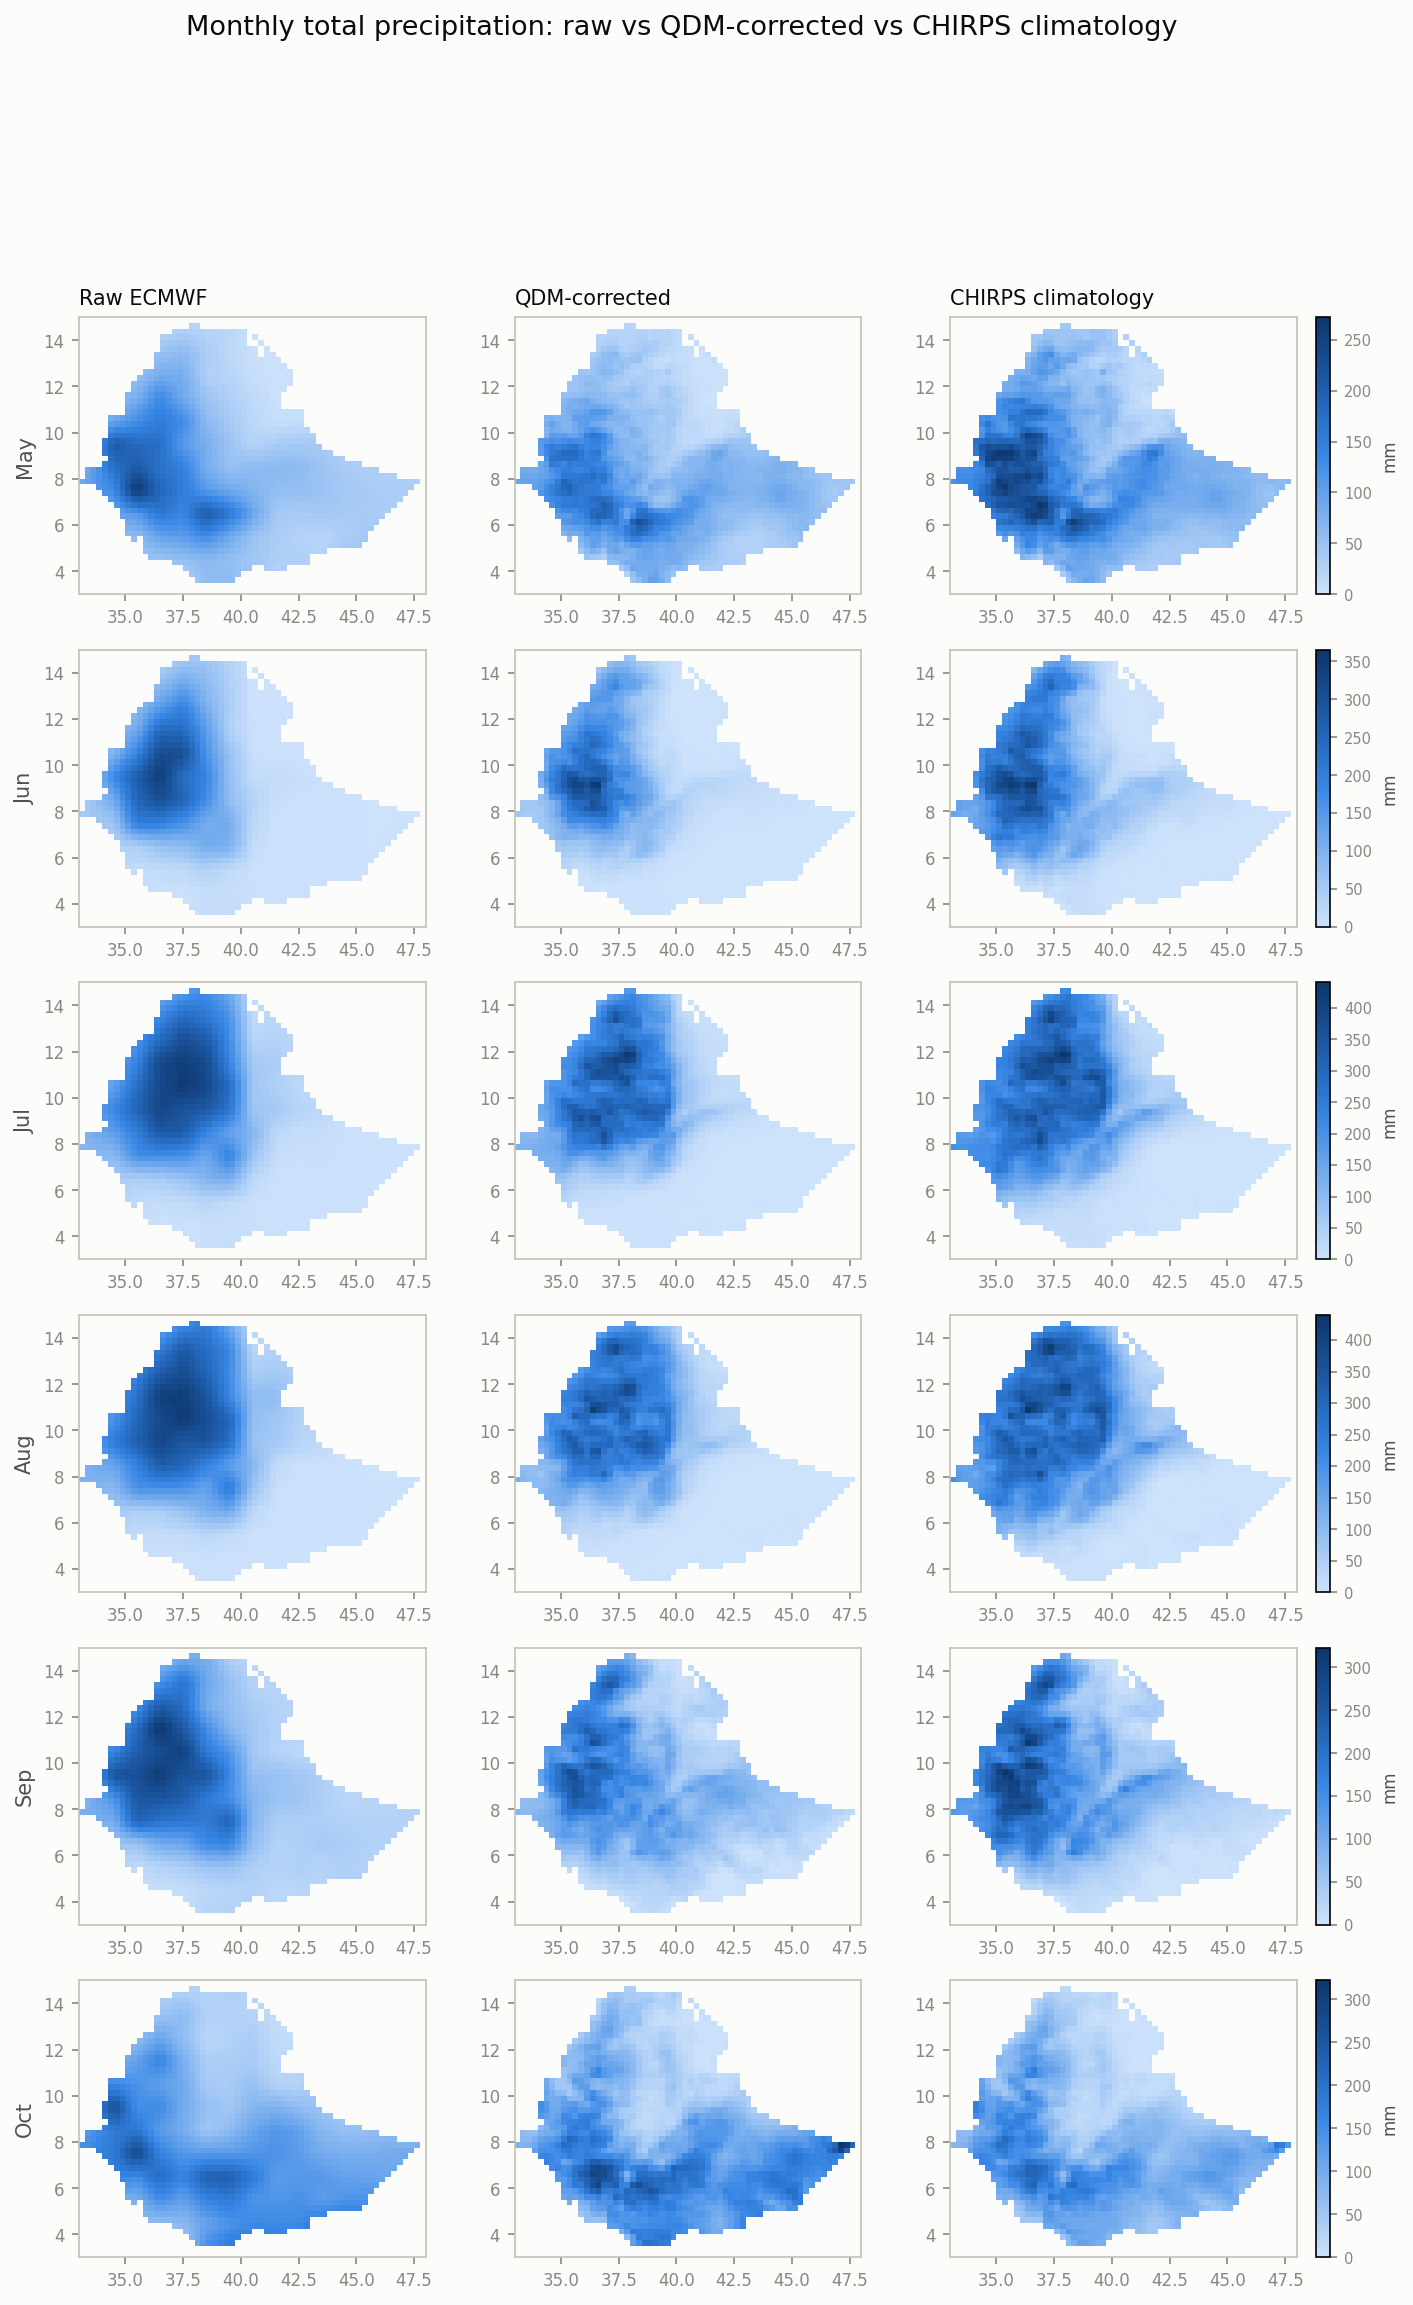

In [26]:
from sbc_qdm.verify.viz import plot_monthly_comparison_grid

raw_2026_m_eth = raw_2026_m.where(eth_mask)
corrected_2026_m_eth = corrected_2026_m.where(eth_mask)
clim_m_eth = clim_m.where(eth_mask)

plot_monthly_comparison_grid(raw_2026_m_eth, corrected_2026_m_eth, clim_m_eth, EVAL_FIGURES_DIR / "monthly_2026_comparison.png")
show(EVAL_FIGURES_DIR / "monthly_2026_comparison.png")

**Reading it:** within Ethiopia, 2026 is below climatology for May/Jun
(e.g. May: 74.1mm raw / 71.5mm corrected vs 99.3mm normal), close to normal
for Jul/Aug (e.g. Aug: 133.8mm raw / 105.6mm corrected vs 136.9mm normal --
notably closer to normal than the full-domain figure, where Aug was clearly
below normal even in the raw forecast), near-normal-to-slightly-above in
September, and above normal in October (111.1mm raw / 108.4mm corrected vs
84.3mm normal). The overall May-Aug "drier than usual" signal from the
full-domain report is present but less pronounced when restricted to
Ethiopia specifically.

### 9.2 Anomaly vs climatology: raw vs corrected

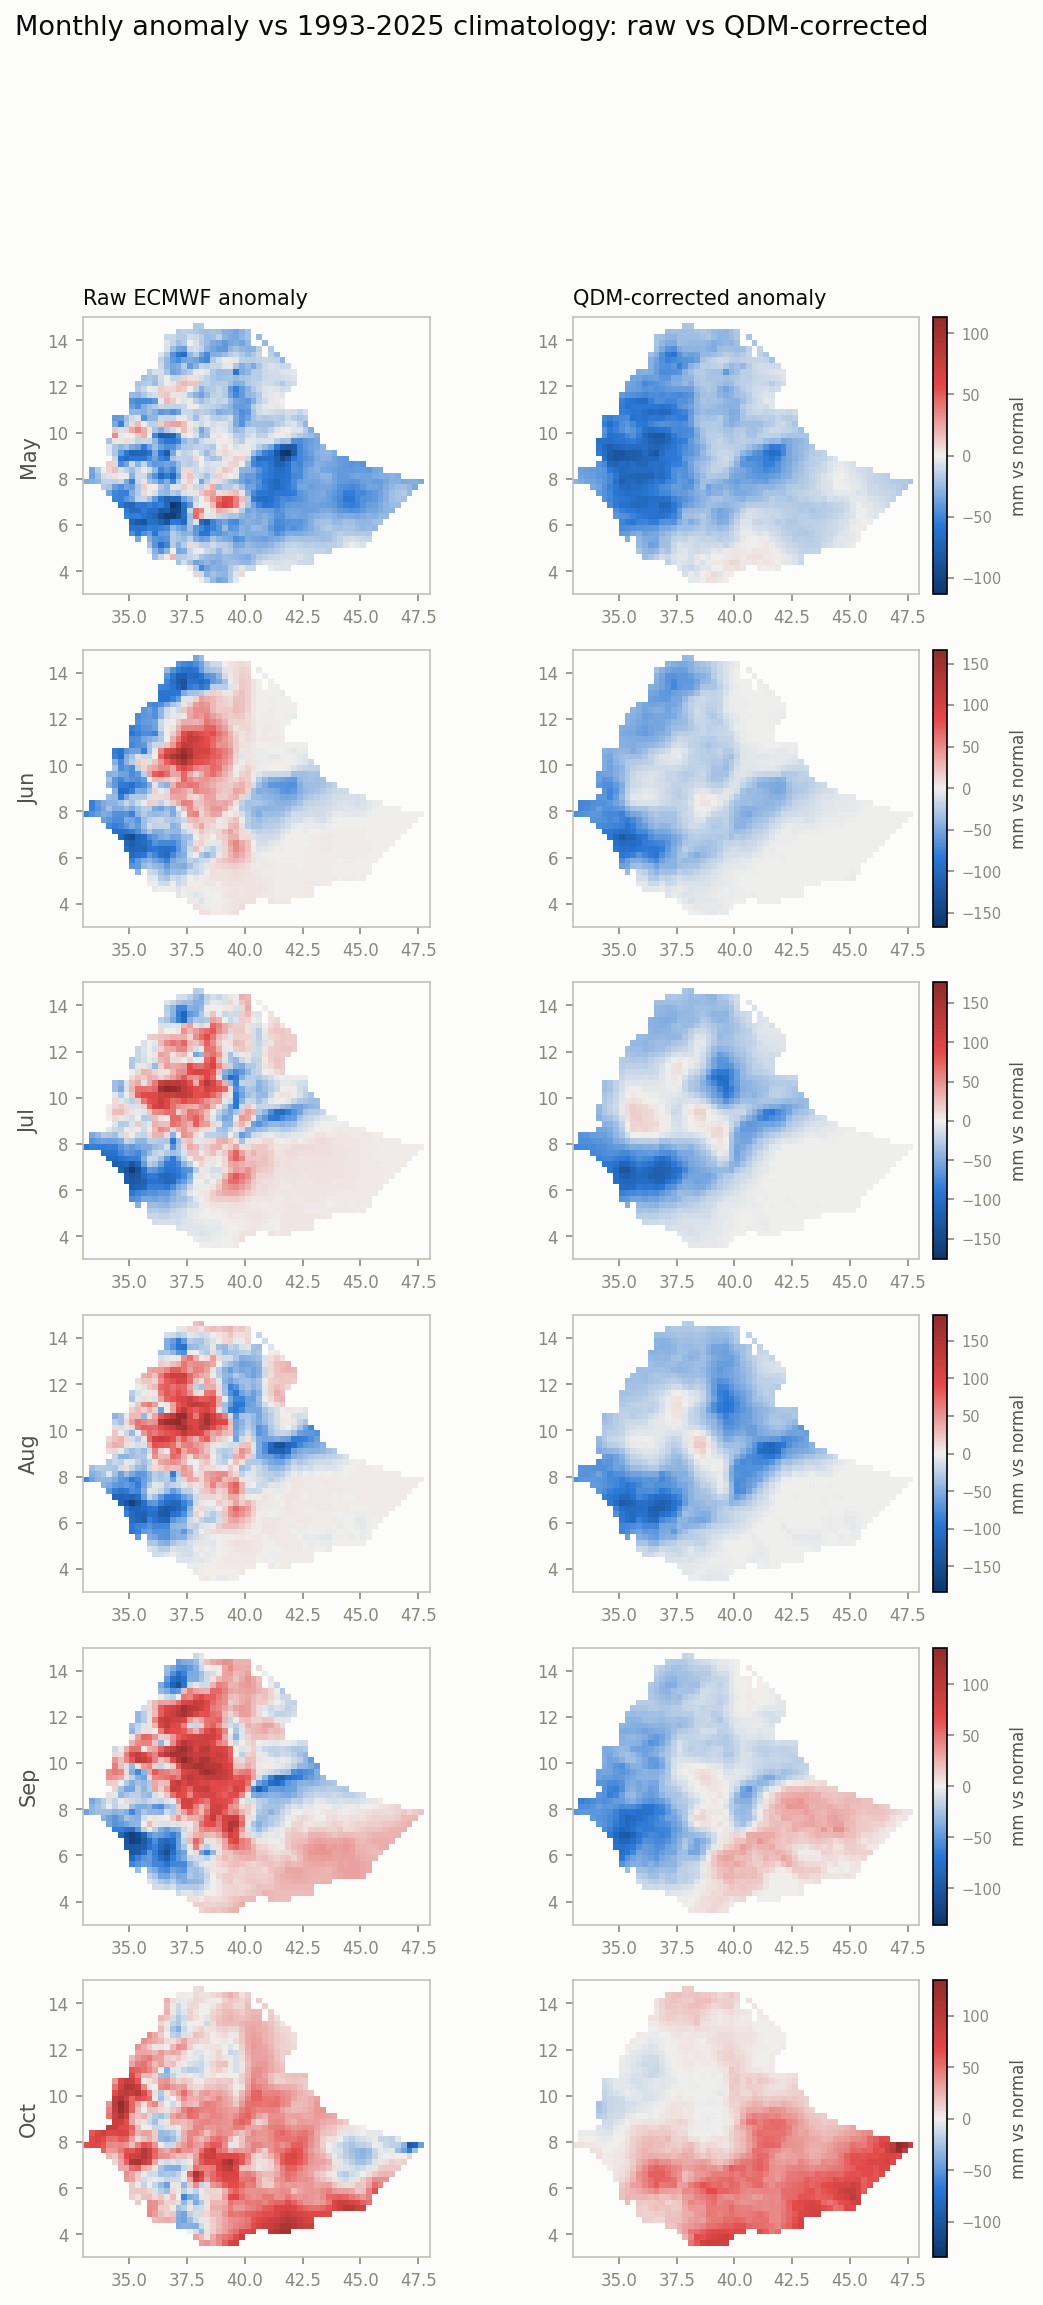

In [27]:
from sbc_qdm.verify.viz import plot_monthly_anomaly_grid

plot_monthly_anomaly_grid(raw_2026_m_eth, corrected_2026_m_eth, clim_m_eth, EVAL_FIGURES_DIR / "monthly_2026_anomaly.png")
show(EVAL_FIGURES_DIR / "monthly_2026_anomaly.png")

**Reading it:** the sign-reversal finding from the full-domain report (raw
shows a wet anomaly in Jun/Jul/Aug where corrected shows a dry one) is
visible here too in the portion of that patch that falls inside Ethiopia
-- consistent with it being driven by the highlands' systematic wet bias
(Section 1.1), which sits mostly within Ethiopia's borders. This reinforces
rather than changes the full-domain report's central caution: an operational
user reading only the raw forecast for Ethiopia's core rainy months would
draw the opposite conclusion (wetter than normal) from what the
bias-corrected forecast actually implies (drier than normal) for the same
region.

## 10. Summary (Ethiopia only)

**What's the same as the full-domain report:**
- QDM removes systematic bias just as thoroughly within Ethiopia (PBIAS
  +14.5% -> -1.9%; JJAS-total RMSE cut ~51%; RPSS/BSS improve substantially
  while ROC skill barely moves -- the same calibration-not-discrimination
  pattern)
- ACC drops slightly after correction here too (0.261 -> 0.211)
- Wet/dry spell persistence and the extreme-quantile amplification caveat
  apply equally (Sections 3-4 are shared with the full-domain report, not
  Ethiopia-specific computations)
- The Jun/Jul/Aug wet-to-dry anomaly sign flip for 2026 is, if anything,
  *more* prominent within Ethiopia -- it's substantially the same
  highlands bias driving both

**What's genuinely different for Ethiopia specifically:**
- Raw bias is proportionally smaller (PBIAS +14.5% vs +31.8% domain-wide) --
  the most-biased, driest pixels sit disproportionately outside Ethiopia's
  border
- Wet-day frequency is higher at both baseline and after correction (33.6%
  raw / 20.8% corrected vs 25.3%/16.3% domain-wide) -- Ethiopia's highlands
  are wetter than the full domain's average
- Interannual variability ratio *improves* toward 1.0 after correction
  within Ethiopia (0.759 -> 0.789), the opposite direction from the full
  domain (1.105 -> 0.831 -- moving further from ideal)
- 2026 JJAS totals are substantially higher in absolute terms (444.0mm raw
  / 352.5mm corrected vs 319.0mm/256.6mm domain-wide), and the May-Aug
  "drier than normal" signal for 2026 is less pronounced than the
  full-domain figures suggested

**Bottom line:** clipping to Ethiopia doesn't change the method's core
strengths and limitations, but it does show they play out somewhat
differently in magnitude across the sub-region that actually matters for
an Ethiopia-focused user -- worth consulting this notebook rather than
assuming the full-domain numbers apply uniformly.